In [ ]:
!pip install transformers[torch] accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 141.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2


In [ ]:
#드라이브 마운트 코드
from google.colab import drive
drive.mount('/content/drive')

import re
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
#tsv 정보 읽기 코드
file_path = '/content/drive/MyDrive/AI/smilestyle_dataset.tsv'

df = pd.read_csv(file_path, sep='\t')
print("--- 원본 데이터 ---")
print(df.head())
print("\n--- 데이터 정보 ---")
df.info()

--- 원본 데이터 ---
                        formal                    informal  \
0       안녕하세요. 저는 고양이 6마리 키워요.          안녕! 나는 고양이 6마리 키워.   
1     고양이를 6마리나요? 키우는거 안 힘드세요?      고양이를 6마리나? 키우는거 안 힘들어?   
2  제가 워낙 고양이를 좋아해서 크게 힘들진 않아요.  내가 워낙 고양이를 좋아해서 크게 힘들진 않아.   
3       가장 나이가 많은 고양이가 어떻게 돼요?       가장 나이가 많은 고양이가 몇 살이야?   
4           여섯 살입니다. 갈색 고양이에요.            여섯 살이야. 갈색 고양이지.   

                           android                                   azae  \
0  휴먼. 반갑다. 안드로이드는. 고양이. 6마리. 소유중.  아이고 안녕하십니까~ 나는 그냥 고양이 6마리 키우고 있는 사람이여   
1             고양이. 6마리. 양육. 번거로운가.        아니 무슨 고양이를 6마리나? 거 키우는 거 안 힘든가?   
2         안드로이드. 고양이. 선호. 힘들지. 않음.        내가 또 워~낙에 고양이를 좋아해서 크게 뭐 힘들진 않고   
3           제일. 나이많은. 고양이. 나이. 무엇.                그려 가장 나이가 많은 고양이가 몇살이여?   
4                    고양이. 갈색. 여섯살.                        6살인데 갈색 고양이 있어~   

                     chat                 choding  \
0     하잉ㅋㅋ 나 떼걸룩 6마리 키운다!      ㅎㅇ 나 주인님 6마리 모심 ㅋㅋ   
1       엥? 6마리나? 안힘듬?ㅋㅋㅋㅋ        6마리? 에바아니냐

In [ ]:
#tsv불러오기 코드

import pandas as pd
import numpy as np
import re
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/AI/smilestyle_dataset.tsv'

df_original = pd.read_csv(file_path, sep='\t')
print("파일을 성공적으로 불러왔습니다.")
print("--- 원본 데이터 정보 ---")
df_original.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
파일을 성공적으로 불러왔습니다.
--- 원본 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3705 entries, 0 to 3704
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   formal      3470 non-null   object
 1   informal    3470 non-null   object
 2   android     1775 non-null   object
 3   azae        1025 non-null   object
 4   chat        3470 non-null   object
 5   choding     3470 non-null   object
 6   emoticon    1797 non-null   object
 7   enfp        1689 non-null   object
 8   gentle      1703 non-null   object
 9   halbae      1794 non-null   object
 10  halmae      1013 non-null   object
 11  joongding   3470 non-null   object
 12  king        1775 non-null   object
 13  naruto      1797 non-null   object
 14  seonbi      1797 non-null   object
 15  sosim       1775 non-null   object
 16  tra

In [ ]:
#데이터 분류 코드
#formal_cols = ['formal', 'gentle', 'king', 'seonbi']
#informal_cols = [
#    'informal', 'azae', 'chat', 'choding',
#    'enfp', 'halbae', 'halmae', 'joongding', 'naruto', 'sosim'
#]

formal_cols = ['formal', 'gentle']
informal_cols = ['informal', 'chat', 'enfp', 'sosim', 'choding', 'joongding']

all_texts = []
all_labels = []

# 3. 존댓말 컬럼에서 문장과 라벨(1)을 추출
for col in formal_cols:
    if col in df_original.columns:
        # 결측치(NaN)를 제외하고 문장만 추출
        texts = df_original[col].dropna().tolist()
        all_texts.extend(texts)
        # 해당 문장 개수만큼 라벨(1) 추가
        all_labels.extend([1] * len(texts))

# 4. 반말 컬럼에서 문장과 라벨(0)을 추출
for col in informal_cols:
    if col in df_original.columns:
        texts = df_original[col].dropna().tolist()
        all_texts.extend(texts)
        # 해당 문장 개수만큼 라벨(0) 추가
        all_labels.extend([0] * len(texts))

# 5. 새로운 데이터프레임을 생성합니다.
df_new = pd.DataFrame({
    'text': all_texts,
    'label': all_labels
})

print(f"--- 데이터 재구성 완료 ---")
print(f"총 문장 개수: {len(df_new)}")
print(df_new.head())
print("\n--- 라벨별 데이터 개수 ---")
print(df_new['label'].value_counts())

--- 데이터 재구성 완료 ---
총 문장 개수: 22517
                          text  label
0       안녕하세요. 저는 고양이 6마리 키워요.      1
1     고양이를 6마리나요? 키우는거 안 힘드세요?      1
2  제가 워낙 고양이를 좋아해서 크게 힘들진 않아요.      1
3       가장 나이가 많은 고양이가 어떻게 돼요?      1
4           여섯 살입니다. 갈색 고양이에요.      1

--- 라벨별 데이터 개수 ---
label
0    17344
1     5173
Name: count, dtype: int64


In [ ]:
# 1. 텍스트 정제 함수 (한글, 공백 제외 모두 제거)
def clean_text(text):
    # 입력이 문자열이 아닐 경우를 대비
    if not isinstance(text, str):
        return ''
    cleaned = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', '', text)
    return cleaned.strip() # 문장 앞뒤 공백 제거

In [ ]:
#전처리 진행

# 'text' 컬럼에 함수 적용
df_new['text'] = df_new['text'].apply(clean_text)
print("--- 텍스트 정제 완료 ---")

# 2. 정제 후 빈 문자열이 된 행 제거
# 예: '!!!'만 있던 문장은 정제 후 ''가 됨
df_new = df_new[df_new['text'] != '']
print(f"빈 문자열 제거 후 데이터 개수: {len(df_new)}")


# 3. 중복된 문장 제거
# keep='first' : 중복된 것 중 첫 번째 값만 남김
df_new.drop_duplicates(subset=['text'], keep='first', inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df_new)}")

# 최종 데이터 확인
print("\n--- 최종 전처리 완료된 데이터 ---")
print(df_new.head())
print("\n--- 최종 라벨별 데이터 개수 ---")
print(df_new['label'].value_counts())

# 인덱스 재정렬 (보기 좋게)
df_final = df_new.reset_index(drop=True)
print("\n--- 최종 데이터 (인덱스 재정렬) ---")
print(df_final.head())

--- 텍스트 정제 완료 ---
빈 문자열 제거 후 데이터 개수: 22517
중복 제거 후 데이터 개수: 21401

--- 최종 전처리 완료된 데이터 ---
                         text  label
0         안녕하세요 저는 고양이 마리 키워요      1
1       고양이를 마리나요 키우는거 안 힘드세요      1
2  제가 워낙 고양이를 좋아해서 크게 힘들진 않아요      1
3       가장 나이가 많은 고양이가 어떻게 돼요      1
4            여섯 살입니다 갈색 고양이에요      1

--- 최종 라벨별 데이터 개수 ---
label
0    16487
1     4914
Name: count, dtype: int64

--- 최종 데이터 (인덱스 재정렬) ---
                         text  label
0         안녕하세요 저는 고양이 마리 키워요      1
1       고양이를 마리나요 키우는거 안 힘드세요      1
2  제가 워낙 고양이를 좋아해서 크게 힘들진 않아요      1
3       가장 나이가 많은 고양이가 어떻게 돼요      1
4            여섯 살입니다 갈색 고양이에요      1


In [ ]:
# 데이터를 훈련용과 검증용으로 분리
train_df, val_df = train_test_split(
    df_final,
    test_size=0.2,       # 20%를 검증용으로 사용
    random_state=42,     # 시드 고정
    stratify=df_final['label']
)

print(f"훈련 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

훈련 데이터 개수: 17120
검증 데이터 개수: 4281


In [ ]:
MODEL_NAME = "monologg/koelectra-small-v3-discriminator"

# 토크나이저 불러오기
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

text = "안녕하세요. 오늘 날씨가 좋네요."
tokens = tokenizer.tokenize(text)
print(f"문장: {text}")
print(f"토큰: {tokens}")

encoding = tokenizer(
    text,
    max_length=128,           # 문장 최대 길이
    padding='max_length',     # 최대 길이에 맞춰 패딩 추가
    truncation=True,          # 최대 길이보다 길면 자르기
    return_tensors='pt'       # PyTorch 텐서로 반환
)
print("\n--- 토크나이저 출력 결과 ---")
print(encoding.keys())
print("Input IDs:", encoding['input_ids'])
print("Attention Mask:", encoding['attention_mask'])

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

문장: 안녕하세요. 오늘 날씨가 좋네요.
토큰: ['안녕', '##하', '##세요', '.', '오늘', '날씨', '##가', '좋', '##네', '##요', '.']

--- 토크나이저 출력 결과 ---
KeysView({'input_ids': tensor([[    2, 11655,  4279,  8553,    18,  6451,  8413,  4070,  3311,  4116,
          4150,    18,     3,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     

In [ ]:
class FormalClassifierDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.text = dataframe.text.values
        self.labels = dataframe.label.values
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        label = self.labels[index]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 데이터셋 생성
train_dataset = FormalClassifierDataset(train_df, tokenizer)
val_dataset = FormalClassifierDataset(val_df, tokenizer)

# 데이터로더 생성
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

NameError: name 'Dataset' is not defined

In [ ]:
import torch.nn as nn

class FormalClassifier(nn.Module):
    def __init__(self, n_classes):
        super(FormalClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        # ELECTRA small 모델의 hidden size는 256
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        # KoELECTRA 모델 실행
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # 토큰에 해당하는 마지막 hidden state를 사용
        # output.last_hidden_state의 shape: (batch_size, sequence_length, hidden_size)
        pooled_output = output.last_hidden_state[:, 0]
        # 분류 레이어 통과
        logits = self.classifier(pooled_output)
        return logits

# 모델 생성 (클래스 2개: 반말, 존댓말)
model = FormalClassifier(n_classes=2)
model.to(device) # 모델을 GPU로 이동

NameError: name 'AutoModel' is not defined

In [ ]:
EPOCHS = 5
optimizer = AdamW(model.parameters(), lr=2e-5) # torch.optim의 AdamW를 사용
loss_fn = nn.CrossEntropyLoss().to(device)

# 학습 루프
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = accuracy_score(all_labels, all_preds)

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.4f}")

Epoch 1/5
Train Loss: 0.0046 | Val Loss: 0.0177 | Val Accuracy: 0.9974
Epoch 2/5
Train Loss: 0.0042 | Val Loss: 0.0114 | Val Accuracy: 0.9981
Epoch 3/5
Train Loss: 0.0033 | Val Loss: 0.0103 | Val Accuracy: 0.9981
Epoch 4/5
Train Loss: 0.0034 | Val Loss: 0.0115 | Val Accuracy: 0.9979
Epoch 5/5
Train Loss: 0.0028 | Val Loss: 0.0091 | Val Accuracy: 0.9991


In [ ]:
def predict(text, model, tokenizer, device, max_len=128):
    model.eval() # 평가 모드로 설정

    encoding = tokenizer.encode_plus(
        clean_text(text),
        add_special_tokens=True,
        max_length=max_len,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )

    # 데이터를 GPU로 이동
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        # 소프트맥스를 적용하여 확률로 변환
        probs = torch.softmax(outputs, dim=1)
        # 가장 확률이 높은 클래스의 인덱스를 예측값으로 사용
        prediction = torch.argmax(probs, dim=1).item()

    label_map = {0: '반말', 1: '존댓말'}
    confidence = probs[0][prediction].item()

    #print(f"입력 문장: '{text}'")
    #print(f"예측 결과: {label_map[prediction]} (확률: {confidence:.4f})")
    #print("-" * 30)
    print(f"{text} - {label_map[prediction]} ({confidence:.4f})")

# 테스트
predict("반갑다냥", model, tokenizer, device)
predict("안녕하세요냥", model, tokenizer, device)
predict("너무 웃겨요 ㅋㅋ", model, tokenizer, device)
predict("혹시 내일 시간 괜찮아?", model, tokenizer, device)
predict("행복해요 (^^)", model, tokenizer, device)
predict("머리부터 발끝까지 다 사랑스러워", model, tokenizer, device)
predict("머리부터 발끝까지 다 사랑스러워요", model, tokenizer, device)
predict("너 뭐야요", model, tokenizer, device)
predict("저번에 교수님께서 자료 가져오라고 하셨는데 기억 나?", model, tokenizer, device)
predict("안녕하세용 반가워용 ㅎㅎ", model, tokenizer, device)
predict("안녕 반가워 ㅎㅎ", model, tokenizer, device)
predict("안녕하세?요", model, tokenizer, device)
predict("안?녕", model, tokenizer, device)
predict("만나서 반갑습니다", model, tokenizer, device)

반갑다냥 - 반말 (0.9996)
안녕하세요냥 - 존댓말 (0.9958)
너무 웃겨요 ㅋㅋ - 존댓말 (0.9991)
혹시 내일 시간 괜찮아? - 반말 (0.9997)
행복해요 (^^) - 존댓말 (0.9993)
머리부터 발끝까지 다 사랑스러워 - 반말 (0.9997)
머리부터 발끝까지 다 사랑스러워요 - 존댓말 (0.9992)
너 뭐야요 - 존댓말 (0.9988)
저번에 교수님께서 자료 가져오라고 하셨는데 기억 나? - 반말 (0.9995)
안녕하세용 반가워용 ㅎㅎ - 존댓말 (0.8977)
안녕 반가워 ㅎㅎ - 반말 (0.9997)
안녕하세?요 - 존댓말 (0.9993)
안?녕 - 반말 (0.9996)
만나서 반갑습니다 - 존댓말 (0.9989)


In [ ]:
# 모델과 토크나이저를 저장할 경로 설정
SAVE_PATH = '/content/drive/MyDrive/AI/'

# 경로가 없으면 생성
import os
os.makedirs(SAVE_PATH, exist_ok=True)

# 모델의 state_dict 저장 (PyTorch 표준 방식)
torch.save(model.state_dict(), os.path.join(SAVE_PATH, 'pytorch_model.bin'))

# 모델의 설정 파일 저장
model.bert.config.to_json_file(os.path.join(SAVE_PATH, "config.json"))

# 토크나이저 저장
tokenizer.save_pretrained(SAVE_PATH)

print(f"모델과 토크나이저가 '{SAVE_PATH}'에 성공적으로 저장되었습니다.")

NameError: name 'torch' is not defined

In [ ]:
import torch.nn as nn

class FormalClassifier(nn.Module):
    def __init__(self, n_classes, model_name):
        super(FormalClassifier, self).__init__()
        config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name, config=config)
        self.classifier = nn.Linear(config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = output.last_hidden_state[:, 0]
        logits = self.classifier(pooled_output)
        return logits

In [ ]:
LOAD_PATH = '/content/drive/MyDrive/AI/'
BASE_MODEL_NAME = "monologg/koelectra-small-v3-discriminator"


# 1. 빈 모델 구조(설계도) 생성
# n_classes=2 (반말/존댓말), 학습 시 사용한 모델 이름을 전달
loaded_model = FormalClassifier(n_classes=2, model_name=BASE_MODEL_NAME)

# 2. 저장된 가중치(state_dict)를 빈 모델에 덮어쓰기
model_weights_path = os.path.join(LOAD_PATH, 'pytorch_model.bin')
loaded_model.load_state_dict(torch.load(model_weights_path, map_location=device))

loaded_model.to(device)
loaded_model.eval()

# 3. 토크나이저 불러오기
loaded_tokenizer = AutoTokenizer.from_pretrained(LOAD_PATH)

model = loaded_model
tokenizer = loaded_tokenizer

print("저장된 모델과 토크나이저를 성공적으로 불러왔습니다.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/458 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/56.6M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

저장된 모델과 토크나이저를 성공적으로 불러왔습니다.


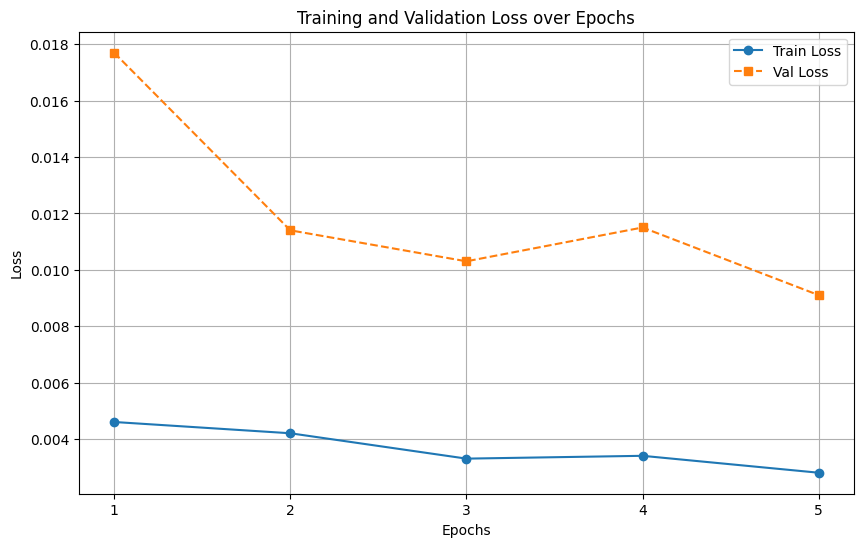

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
train_loss = [0.0046, 0.0042, 0.0033, 0.0034, 0.0028]
val_loss = [0.0177, 0.0114, 0.0103, 0.0115, 0.0091]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle='-')
plt.plot(epochs, val_loss, label='Val Loss', marker='s', linestyle='--')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs) # x축 눈금을 정수로 표시
plt.legend()
plt.grid(True)

plt.savefig('loss_graph.png') # 파일로 저장
plt.show()